In [9]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1", on_bad_lines="skip")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
## Data Cleaning
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.shape

(397884, 8)

In [4]:
## Feature Engineering
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['hour'] = df['InvoiceDate'].dt.hour
df['day'] = df['InvoiceDate'].dt.day_name()

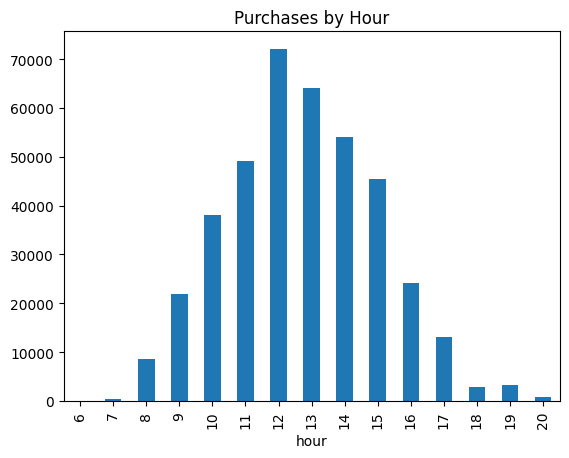

In [7]:
## Exploratory Data Analysis
import matplotlib.pyplot as plt
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Purchases by Hour")
plt.show()

Purchases are concentrated in certain hours, suggesting possible impulsive buying patterns.

In [8]:
## Hypothesis Testing
from scipy.stats import ttest_ind
night = df[df['hour'] >= 18]['Quantity']
day = df[df['hour'] < 18]['Quantity']
ttest_ind(night, day)

TtestResult(statistic=np.float64(0.38185043550585357), pvalue=np.float64(0.7025725100448659), df=np.float64(397882.0))

This test compares evening and daytime purchases. If a significant difference is observed, it may indicate differences in purchasing behavior related to time.

The p-value is relatively high, suggesting that there is no strong statistical evidence of a difference between evening and daytime purchases.